In [ ]:
# Sales Data Analysis Dashboard

This project analyzes sales data to discover business insights
such as sales performance, profit trends, regional performance,
and product category analysis using Python.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("C:\\Users\\DELL\\Documents\\Jupyter\\SampleSuperstore.csv")

In [8]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [9]:
df.shape

(9994, 13)

In [10]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [12]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [13]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
df.columns = df.columns.str.strip()

In [15]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
## Dataset Description

The dataset contains information about sales transactions
including product category, region, profit, quantity,
discounts, and shipping mode.

Key columns include:
- Category
- Sub-Category
- Region
- Sales
- Profit
- Quantity
- Discount

In [16]:
df['Sales'].sum()

np.float64(2297200.8603)

In [17]:
df['Profit'].sum()

np.float64(286397.0217)

In [18]:
df['Quantity'].sum()

np.int64(37873)

In [19]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [20]:
## Business Insights

1. Technology category generated the highest sales.
2. The West region produced the highest profit.
3. High discounts often resulted in lower profit.
4. Certain sub-categories like Phones and Copiers contributed strongly to revenue.
5. Consumer segment customers generated the largest share of sales.

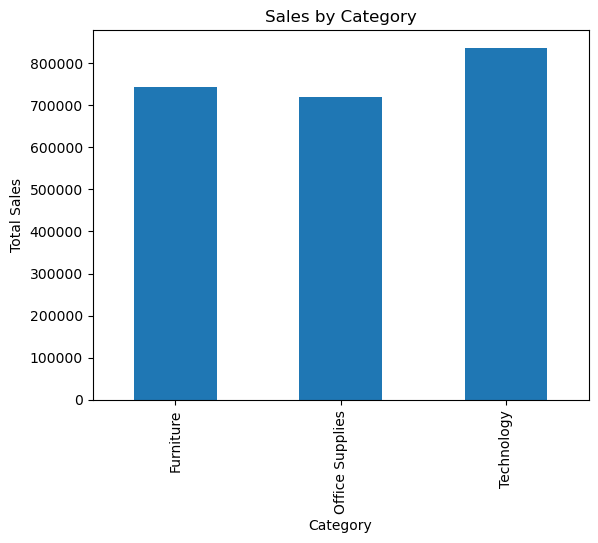

In [21]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

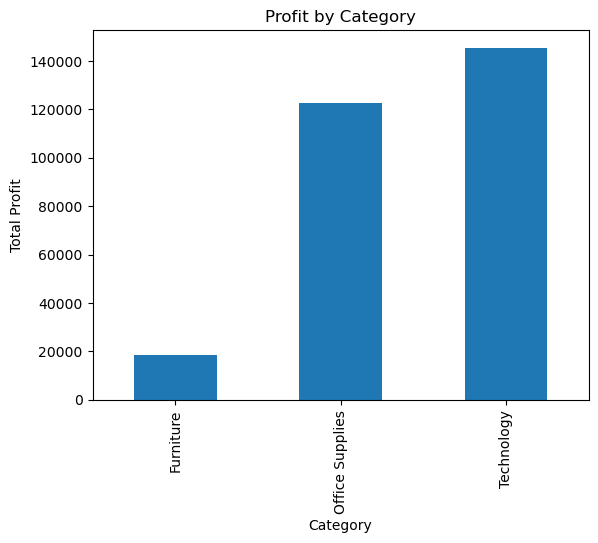

In [22]:
category_profit = df.groupby('Category')['Profit'].sum()

category_profit.plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

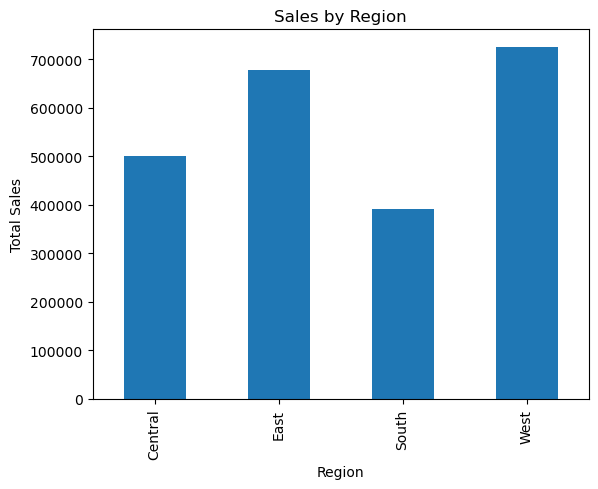

In [23]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

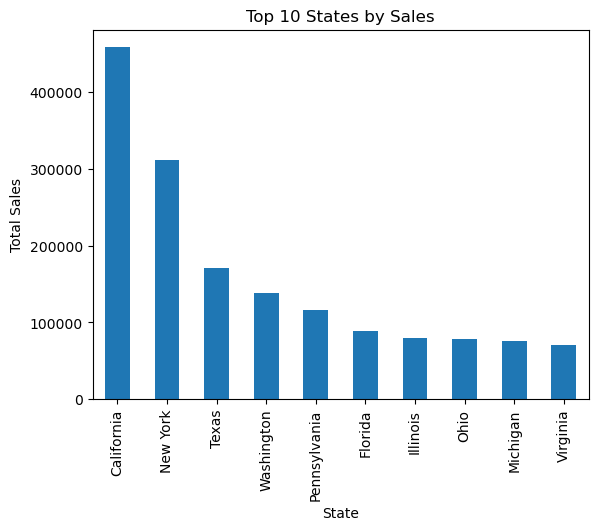

In [24]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar')

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.show()

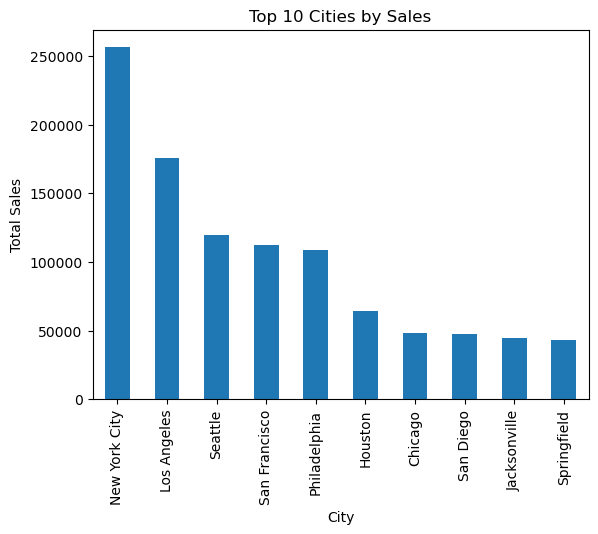

In [25]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind='bar')

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

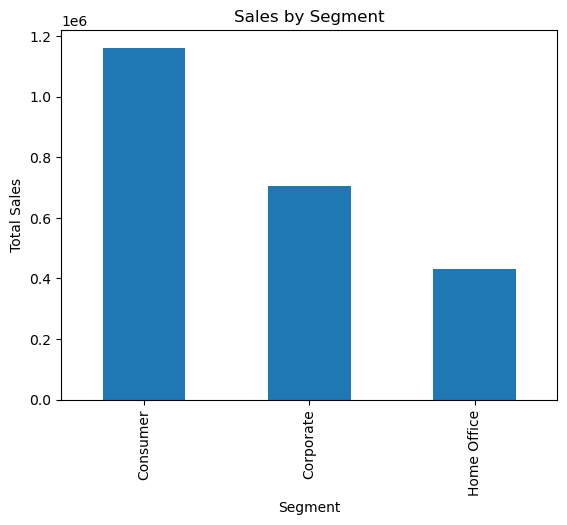

In [26]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='bar')

plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.show()

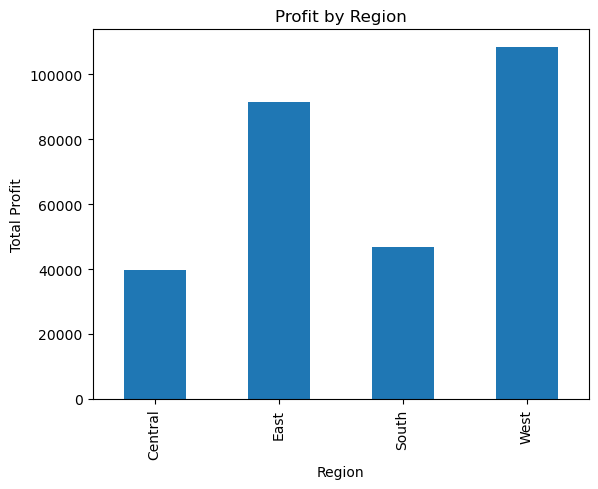

In [27]:
region_profit = df.groupby('Region')['Profit'].sum()

region_profit.plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

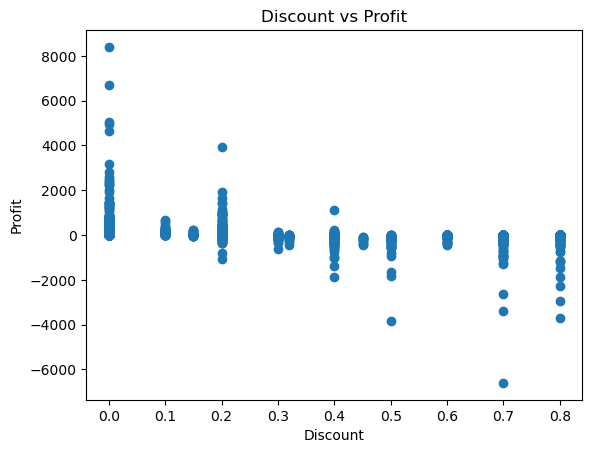

In [28]:
plt.scatter(df['Discount'], df['Profit'])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

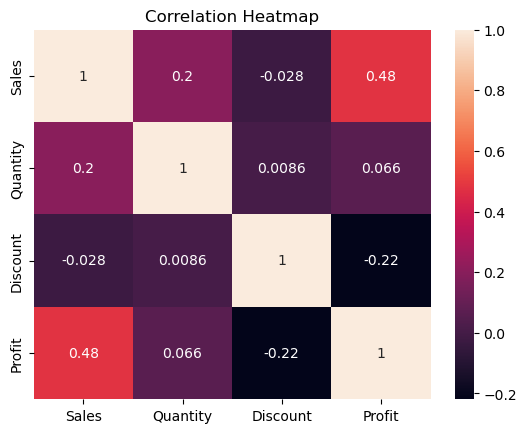

In [29]:
corr = df[['Sales','Quantity','Discount','Profit']].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [34]:
total_sales = df['Sales'].sum()
total_sales

np.float64(2297200.8603)

In [35]:
total_profit = df['Profit'].sum()
total_profit

np.float64(286397.0217)

In [36]:
total_quantity = df['Quantity'].sum()
total_quantity

np.int64(37873)

In [37]:
avg_discount = df['Discount'].mean()
avg_discount

np.float64(0.1562027216329798)

In [38]:
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)
print("Average Discount:", avg_discount)


Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity Sold: 37873
Average Discount: 0.1562027216329798


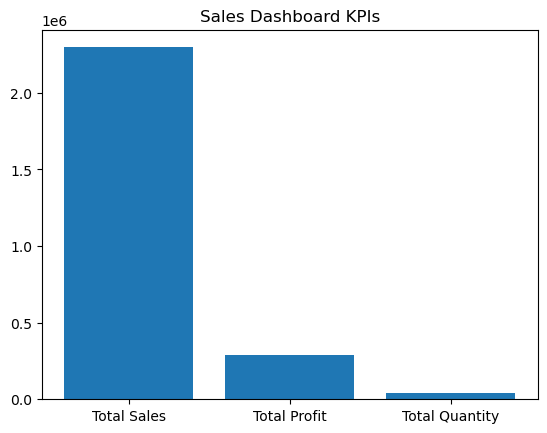

In [39]:
kpi_values = [total_sales, total_profit, total_quantity]

kpi_names = ['Total Sales', 'Total Profit', 'Total Quantity']

plt.bar(kpi_names, kpi_values)

plt.title("Sales Dashboard KPIs")

plt.show()

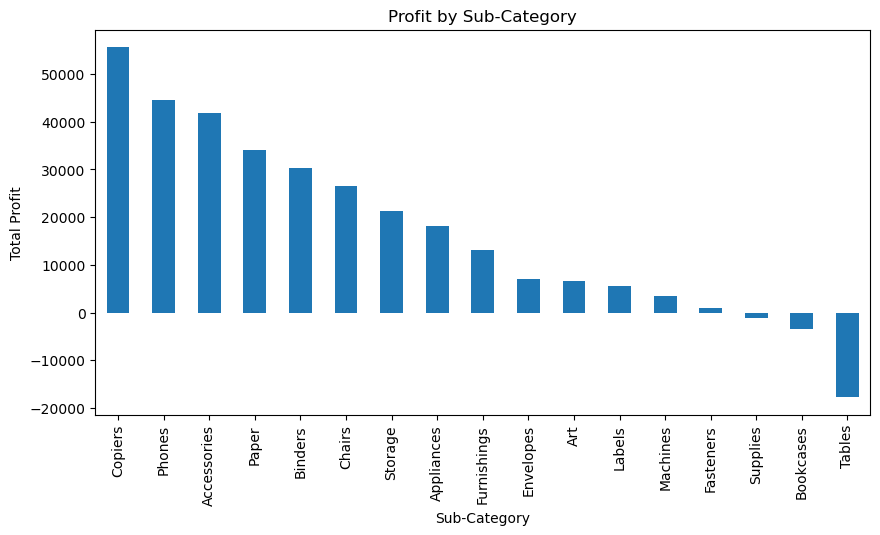

In [40]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

subcat_profit.plot(kind='bar', figsize=(10,5))

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")

plt.show()

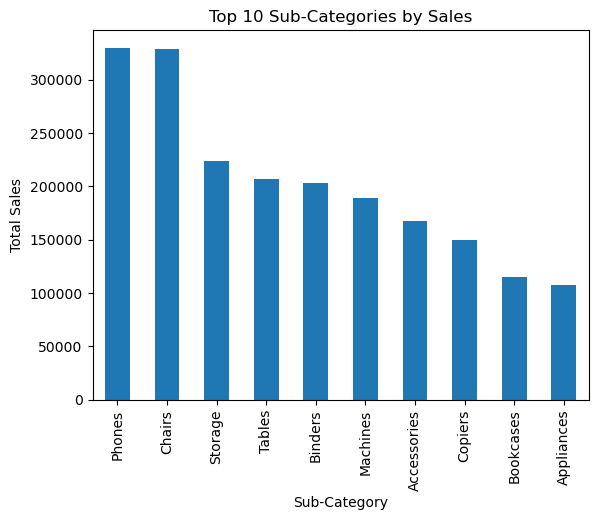

In [41]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.show()

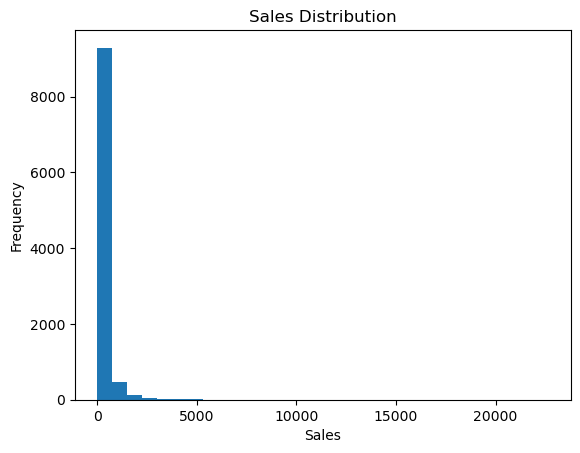

In [42]:
plt.hist(df['Sales'], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

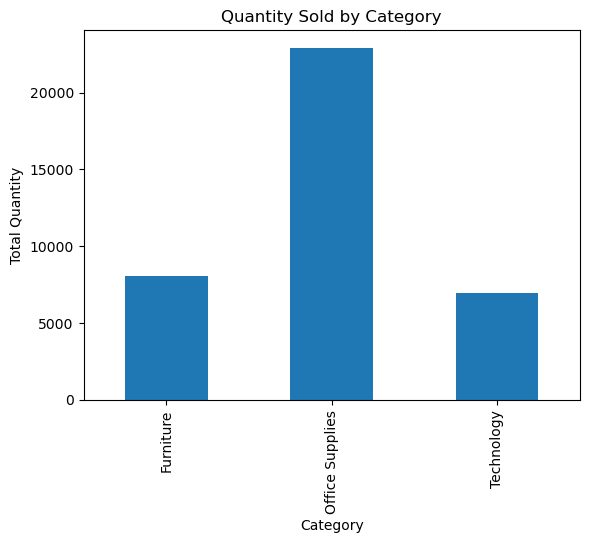

In [43]:
quantity_category = df.groupby('Category')['Quantity'].sum()

quantity_category.plot(kind='bar')

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity")

plt.show()

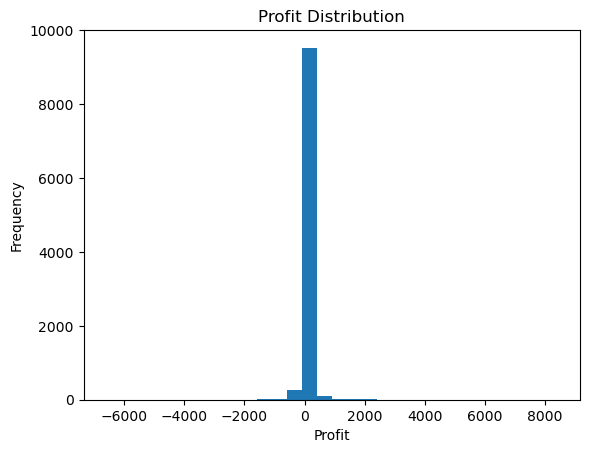

In [44]:
plt.hist(df['Profit'], bins=30)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

In [45]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity:", total_quantity)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity: 37873


In [49]:
sales_category = df.groupby('Category')['Sales'].sum()

profit_region = df.groupby('Region')['Profit'].sum()

top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

In [48]:
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [ ]:
## Dashboard Components

The dashboard includes:

- Sales by Category
- Profit by Region
- Top 10 Products by Sales
- Discount vs Profit Relationship

These visualizations help businesses understand
sales trends and profitability patterns.

Text(0.5, 1.0, 'Sales by Category')

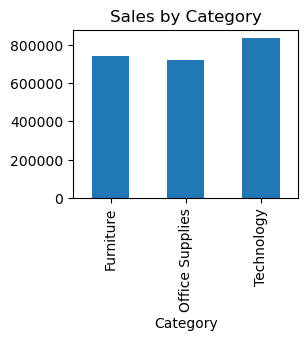

In [50]:
plt.subplot(2,2,1)

sales_category.plot(kind='bar')

plt.title("Sales by Category")

Text(0.5, 1.0, 'Profit by Region')

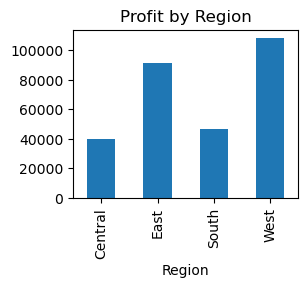

In [51]:
plt.subplot(2,2,2)

profit_region.plot(kind='bar')

plt.title("Profit by Region")

Text(0.5, 1.0, 'Top 10 Products by Sales')

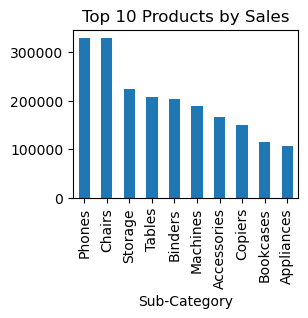

In [52]:
plt.subplot(2,2,3)

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")

Text(0, 0.5, 'Profit')

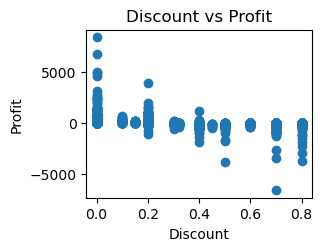

In [53]:
plt.subplot(2,2,4)

plt.scatter(df['Discount'], df['Profit'])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

In [54]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

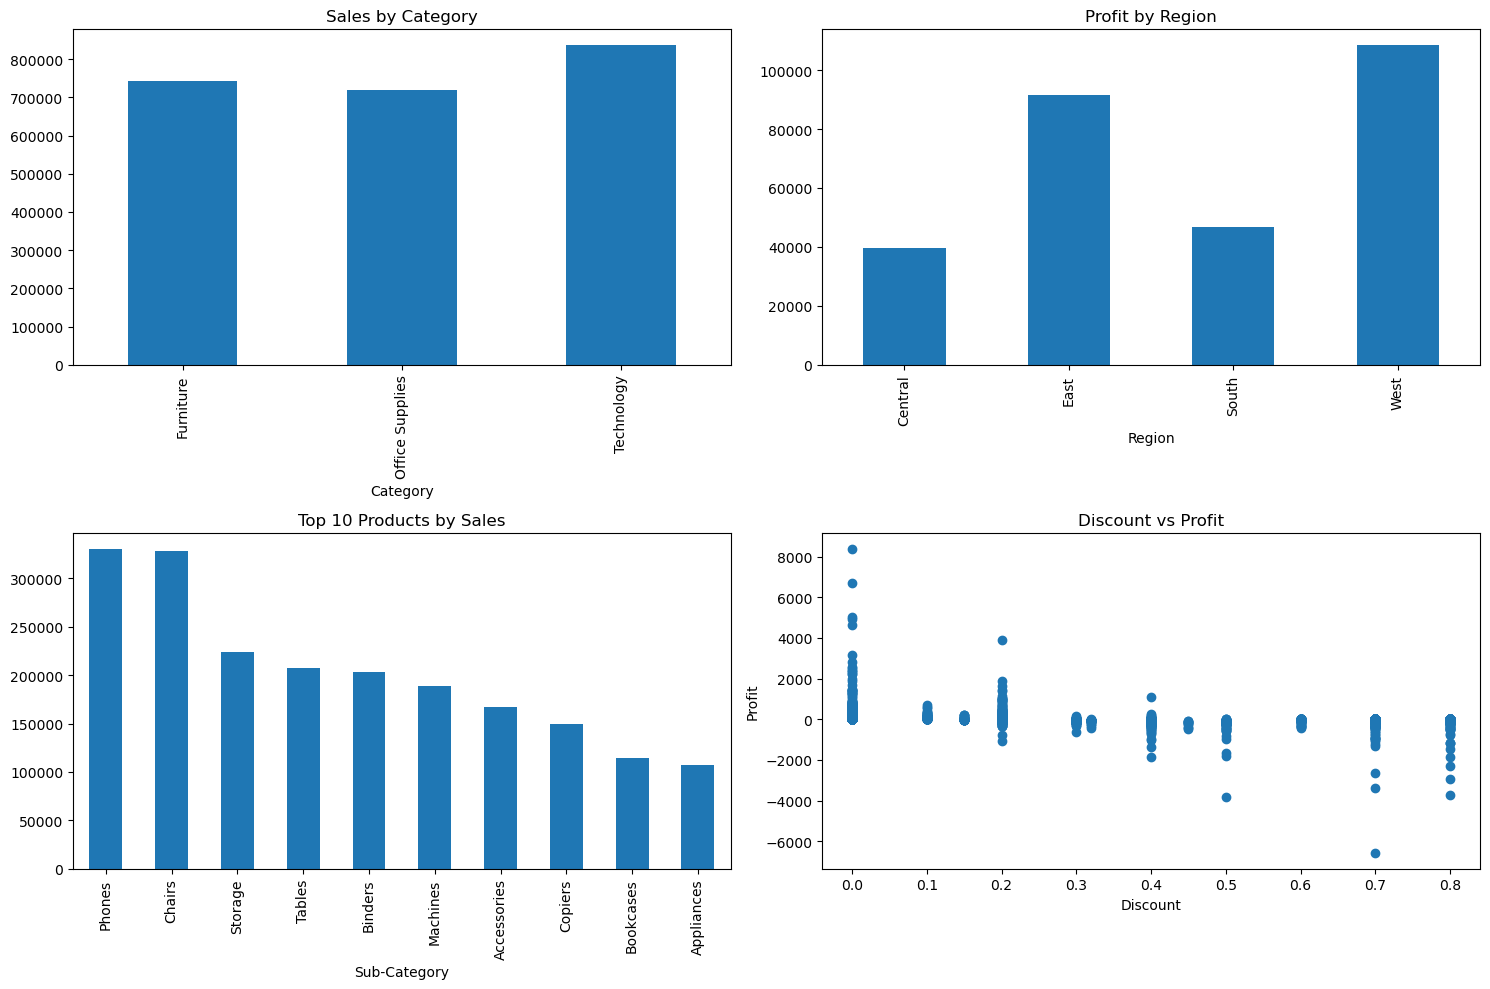

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
sales_category = df.groupby('Category')['Sales'].sum()
profit_region = df.groupby('Region')['Profit'].sum()
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

# Create dashboard layout
plt.figure(figsize=(15,10))

# Chart 1: Sales by Category
plt.subplot(2,2,1)
sales_category.plot(kind='bar')
plt.title("Sales by Category")

# Chart 2: Profit by Region
plt.subplot(2,2,2)
profit_region.plot(kind='bar')
plt.title("Profit by Region")

# Chart 3: Top Products
plt.subplot(2,2,3)
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")

# Chart 4: Discount vs Profit
plt.subplot(2,2,4)
plt.scatter(df['Discount'], df['Profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()